# Parcial II – Gestión Prospectiva de Riesgos

1. cargar librerías

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


 2. Conectar Google Drive

In [7]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


3. Función de Clusterización

In [34]:
def clusterizacion(Xi):

    XC = np.random.choice(Xi, size=5) #separacion en 5 clusters
    XC = np.sort(XC)
    nc = np.zeros((len(Xi),1))

    for k in range(len(Xi)):

        d = np.abs(XC - Xi[k]) #distancia de un dato a una semilla
        nc[k] = np.argmin(d)

        nc2 = np.int32(nc[k])
        XC[nc2,] = (XC[nc2,] + Xi[k]) / 2

    return XC, nc


4. Cargar Base de Datos

In [35]:
nxl = '/content/drive/MyDrive/Integracion de datos y prospectiva/5. Riesgo Operacional FallasTecnológicas.xlsx'
XDB = pd.read_excel(nxl, sheet_name=0)
print(XDB.head())


  Fallas Tecnológicas (Canales Electronicos)             Unnamed: 1  \
0                                     Fechas  Transacciones Diarias   
1                        2009-01-01 00:00:00                     80   
2                        2009-01-02 00:00:00                    105   
3                        2009-01-03 00:00:00                     70   
4                        2009-01-04 00:00:00                    105   

                  Unnamed: 2              Unnamed: 3  \
0  Valor Transado (millones)  Transacciones Fallidas   
1                    14.8058                       1   
2                    56.4721                       4   
3                      9.976                       5   
4                    18.2949                       6   

                           Unnamed: 4  \
0  Valor Generado Promedio (Millones)   
1                              0.5374   
2                              1.1978   
3                              0.4269   
4                              

5. Semilla Aleatoria

In [36]:
np.random.seed(42)

6. Variable de frecuencia

In [38]:
XF = pd.to_numeric(XDB.iloc[1:,3]).to_numpy()
XCf, ncf = clusterizacion(XF)

print('Clusters Frecuencia')
print(XCf)

Clusters Frecuencia
[1 3 5 9 7]


 7. Variable de Severidad

In [15]:
XS = pd.to_numeric(XDB.iloc[1:,4]).to_numpy()

XCs, ncs = clusterizacion(XS)

print('Clusters Severidad')
print(XCs)

Clusters Severidad
[ 0.37394726  1.16281852  3.80911082  7.25499828 12.98181998]


8. Distribución Agregada de Pérdidas (LDA)

In [16]:
LDA = XF * XS

XClda, nclda = clusterizacion(LDA)

print('Clusters LDA')
print(XClda)


Clusters LDA
[ 2.92593623  9.92371513 27.70398472 44.94831585 62.82279007]


9. Construcción del DataFrame

In [18]:
df = pd.DataFrame(
    np.column_stack((XF, ncf, XS, ncs, LDA, nclda, XDB.iloc[1:,5]))
)

df.columns = [
    'Frecuencia',
    'Nivel_Frecuencia',
    'Severidad',
    'Nivel_Severidad',
    'LDA',
    'Nivel_LDA',
    'Tipo_Riesgo'
]

print(df.head())

  Frecuencia Nivel_Frecuencia Severidad Nivel_Severidad     LDA Nivel_LDA  \
0          1              0.0    0.5374             1.0  0.5374       0.0   
1          4              1.0    1.1978             2.0  4.7912       2.0   
2          5              1.0    0.4269             1.0  2.1345       1.0   
3          6              2.0    1.0814             2.0  6.4884       3.0   
4          7              2.0    1.2105             2.0  8.4735       3.0   

                                         Tipo_Riesgo  
0  Errores visuales menores, problemas de usabili...  
1  Errores en la interfaz de usuario, fallas en f...  
2  Errores visuales menores, problemas de usabili...  
3  Errores en la interfaz de usuario, fallas en f...  
4  Errores en la interfaz de usuario, fallas en f...  


 10. Resultados

In [21]:
df.to_excel('Matriz_Riesgo_FINTECH.xlsx', index=False)
print('Archivo exportado correctamente')

from google.colab import files
files.download('Matriz_Riesgo_FINTECH.xlsx')

Archivo exportado correctamente


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

11. Construcción de la matriz de riesgo

In [22]:
MEf = np.zeros((5,5))
MEs = np.zeros((5,5))

for k in range(len(XF)):

    nf = np.int32(df.iloc[k,1])
    nc = np.int32(df.iloc[k,3])

    MEf[nf,nc] = MEf[nf,nc] + XF[k]
    MEs[nf,nc] = (MEs[nf,nc] + XS[k]) / 2


12. Heatmap Matriz de Frecuencia

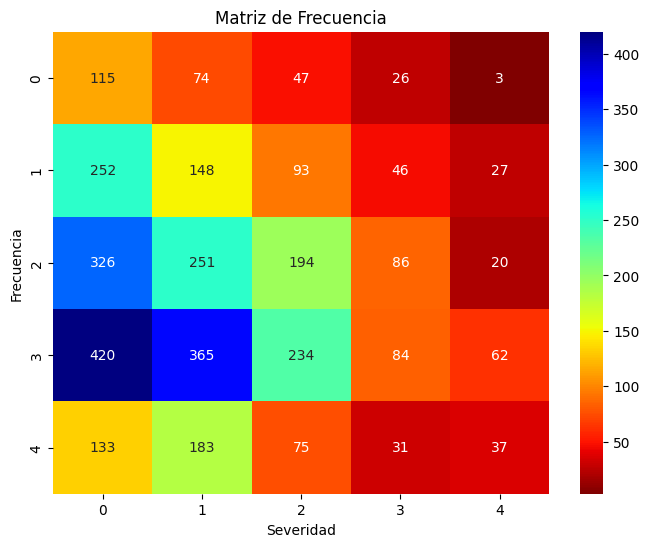

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(
    MEf,
    annot=True,
    fmt='.0f',
    cmap='jet_r'
)

plt.title('Matriz de Frecuencia')
plt.xlabel('Severidad')
plt.ylabel('Frecuencia')
plt.show()


13. Heatmap Matriz de Severidad

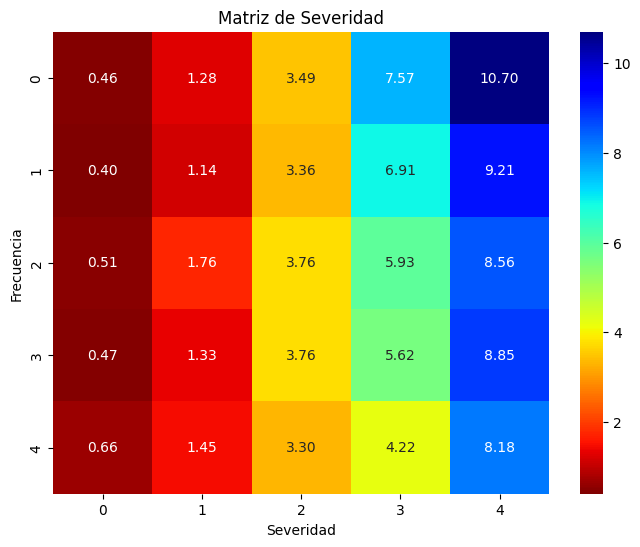

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    MEs,
    annot=True,
    fmt='.2f',
    cmap='jet_r'
)

plt.title('Matriz de Severidad')
plt.xlabel('Severidad')
plt.ylabel('Frecuencia')
plt.show()


14. Matriz de Impacto

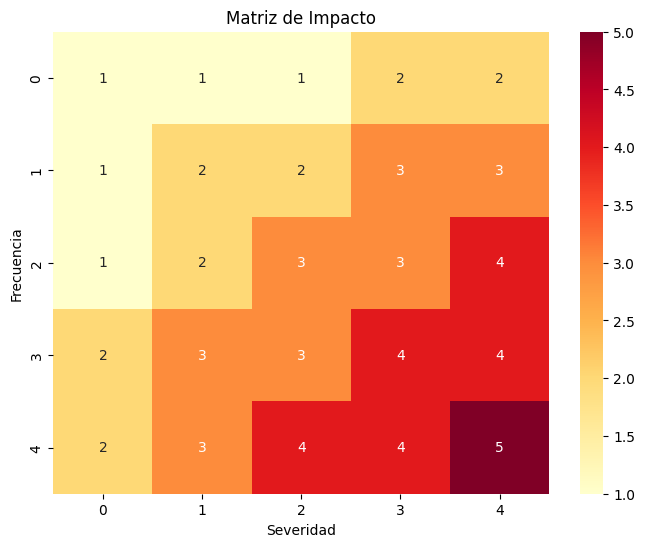

In [39]:
MI = np.array([
    [1,1,1,2,2],
    [1,2,2,3,3],
    [1,2,3,3,4],
    [2,3,3,4,4],
    [2,3,4,4,5]
])

plt.figure(figsize=(8,6))

sns.heatmap(
    MI,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd'
)

plt.title('Matriz de Impacto')
plt.xlabel('Severidad')
plt.ylabel('Frecuencia')
plt.show()


15. Matriz de Gestión

Ingresar nivel de gestión (1,2,3,4): 3


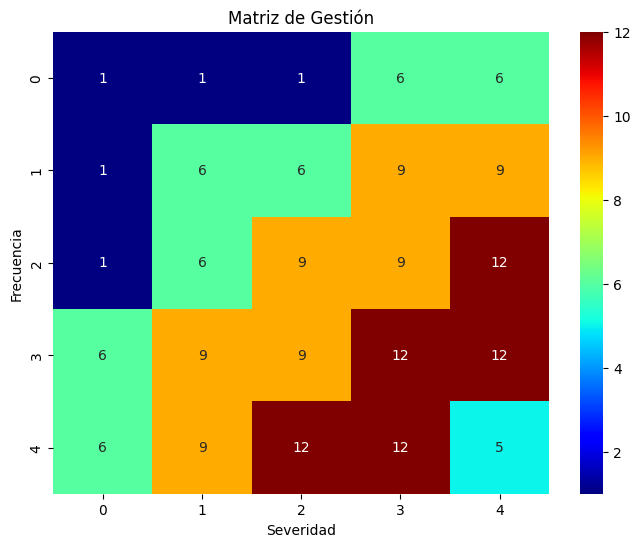

In [26]:
NG = np.int32(input('Ingresar nivel de gestión (1,2,3,4): '))

MG = np.copy(MI)

for i in range(5):
    for j in range(5):

        if MG[i,j] > 1 and MG[i,j] < 5:
            MG[i,j] = MG[i,j] * NG

plt.figure(figsize=(8,6))

sns.heatmap(
    MG,
    annot=True,
    fmt='.0f',
    cmap='jet'
)

plt.title('Matriz de Gestión')
plt.xlabel('Severidad')
plt.ylabel('Frecuencia')
plt.show()


16. Pérdidas Esperadas y Riesgo

In [27]:
ps = np.mean(MEs)
pp = np.sum(MEf * MEs) / np.sum(MEf)

print('Promedio simple severidad:', ps)
print('Promedio ponderado:', pp)


Promedio simple severidad: 4.116066961216344
Promedio ponderado: 2.199678106984677


17. Pérdida Ponderada por Riesgo y Gestión

In [40]:
pnr = np.sum(MEf * MEs * MI) / np.sum(MEf * MI)

png = np.sum(MEf * MEs * MI) / np.sum(MEf * MG)

print('Pérdida ponderada por riesgo:', pnr)
print('Pérdida ponderada por gestión:', png)


Pérdida ponderada por riesgo: 2.8225769815964656
Pérdida ponderada por gestión: 1.0307087343177994


18. Consulta de Riesgo

In [29]:
fila = np.int32(input('Ingresar nivel frecuencia: '))
col = np.int32(input('Ingresar nivel severidad: '))

consulta = df[
    (df.iloc[:,1] == fila) &
    (df.iloc[:,3] == col)
]

print(consulta)


Ingresar nivel frecuencia: 3
Ingresar nivel severidad: 2
    Frecuencia Nivel_Frecuencia Severidad Nivel_Severidad      LDA Nivel_LDA  \
11          12              3.0    1.7533             2.0  21.0396       3.0   
20          10              3.0    1.4141             2.0   14.141       3.0   
25           9              3.0    1.1105             2.0   9.9945       2.0   
46           9              3.0    1.6694             2.0  15.0246       3.0   
116          8              3.0    1.6379             2.0  13.1032       2.0   
118          8              3.0    3.3024             2.0  26.4192       3.0   
125          8              3.0    1.9707             2.0  15.7656       2.0   
147         12              3.0    2.3534             2.0  28.2408       3.0   
155          9              3.0    2.0749             2.0  18.6741       2.0   
173         10              3.0    2.3131             2.0   23.131       3.0   
198         14              3.0    2.8104             2.0  39.3

** Analisis de resultados**

El promedio simple de severidad de los eventos de fallas tecnologicas fue de 4.11, esto representa el costo promedio que tiene un evento de riesgo para la FINTECH.

De acuerdo con el promedio ponderado se puede ver que un evento de riesgo en promedio puede costar alrededor de 2.19, este es un valor inferior al promedio simple debido a la frecuencia de ocurrencia de los eventos.

De acuerdo con la integracion de la matriz de impacto, se puede ver que la perdida esperada se incrementa a 2.82 por la importancia que tienen los eventos clasificados en los niveles altos de frecuencia y severidad dentro de la matriz de riesgos.

Podemos observar para un nivel de gestion implementado, que la perdida esperada se redujo a 1.03, tomando como referencia la perdida esperada que incluye el impacto. Esto demuestra que una mayor gestion de riesgos permite disminuir las perdidas operacionales.

**Matriz de impacto **

Esta matriz indica el nivel de impacto que tiene cada evento de falla tecnologica dentro de la matriz de eventos de riesgo sobre las finanzas de la organizacion.

**Matriz de gestion**

Esta matriz es un complemento de la matriz de impacto porque indica la atencion que se le debe dar a cada nivel de riesgo. La matriz de gestion tiene costos asociados con la atencion y control de un riesgo. Pero el aumento de gestion permite disminuir las perdidas catastroficas.




19. Losses y OpVaR esperada

In [30]:
LC1 = np.mean(LDA)

OpVar = np.percentile(LDA, 99.9)

print('Expected Losses (EL):', LC1)
print('Operational Value at Risk (OpVaR):', OpVar)


Expected Losses (EL): 9.45111269614836
Operational Value at Risk (OpVaR): 102.9021000000008


20. Clasificación de Riesgos

In [31]:
nc_c1 = np.sum(df[df.iloc[:,4] < LC1].iloc[:,0])
nc_c3 = np.sum(df[df.iloc[:,4] > OpVar].iloc[:,0])
nc_c2 = np.sum(df.iloc[:,0]) - nc_c1 - nc_c3

print('Eventos C1:', nc_c1)
print('Eventos C2:', nc_c2)
print('Eventos C3:', nc_c3)


Eventos C1: 1952
Eventos C2: 1370
Eventos C3: 10


**Caso de estudio 2**

Se procedio con la caracterizacion de la distribucion agregada de las perdidas (LDA: Loss Distribution Approach) y sus parametros de riesgo.

C1: Perdidas esperadas = 1952 eventos.

C2: Perdidas no esperadas = 1370 eventos.

C3: Perdidas catastroficas = 10 eventos.

Las perdidas esperadas (Expected Losses) fueron de 9.45, mientras que el Operational Value at Risk (OpVaR) fue de 102.90, esto represneta los eventos extremos asociados con fallas tecnologicas criticas.

21. Valor Capturado Financiero y GEI

In [32]:
VCF = (pp - png) * 100

GEI = VCF * 0.15

print('Valor Capturado Financiero:', VCF)
print('Indicador Potencial Captura GEI:', GEI)


Valor Capturado Financiero: 116.89693726668777
Indicador Potencial Captura GEI: 17.534540590003164


22. Histograma LDA

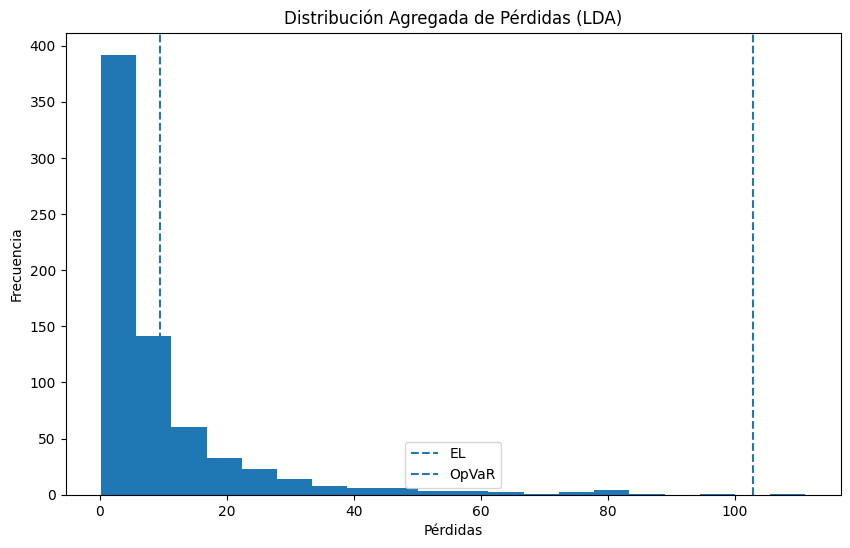

In [33]:
plt.figure(figsize=(10,6))

plt.hist(LDA, bins=20)

plt.axvline(
    LC1,
    linestyle='--',
    label='EL'
)

plt.axvline(
    OpVar,
    linestyle='--',
    label='OpVaR'
)

plt.title('Distribución Agregada de Pérdidas (LDA)')
plt.xlabel('Pérdidas')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()


# Conclusiones

De los resultados que se obtuvieron se puede verr que la gestion prospectiva de riesgos permitio disminuir la exposicion a perdidas operacionales dentro de la FINTECH, se redujo la perdida ponderada de 2.82 a 1.03 gracias a la aplicacion de estrategias de gestion del riesgo.

El valor capturado financiero fue de 116.89, esto muestra los beneficios financieros de implementar modelos de gestion prospectiva sobre eventos de fallas tecnologicas.

Y tambien se puede observar tambien que el indicador potencial de captura GEI fue de 17.53, esto muestra que una mejor gestion operativa puede contribuir a optimizar recursos y reducir impactos asociados con la operacion tecnologica.

Por ultimo el modelo K-Means y la distribucion agregada de perdidas permitieron clasificar los riesgos segun su frecuencia y severidad esto facilita la toma de decisiones y el fortalecimiento de las estrategias de gestion del riesgo operacional.
